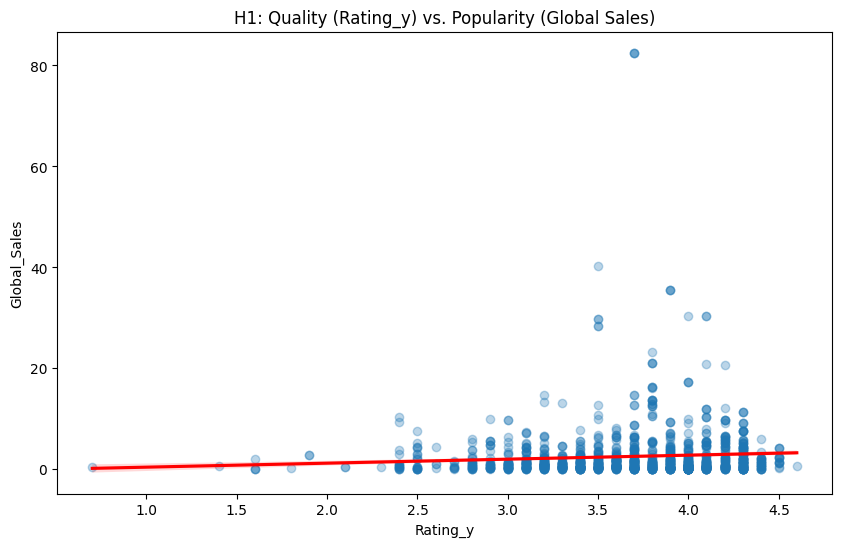

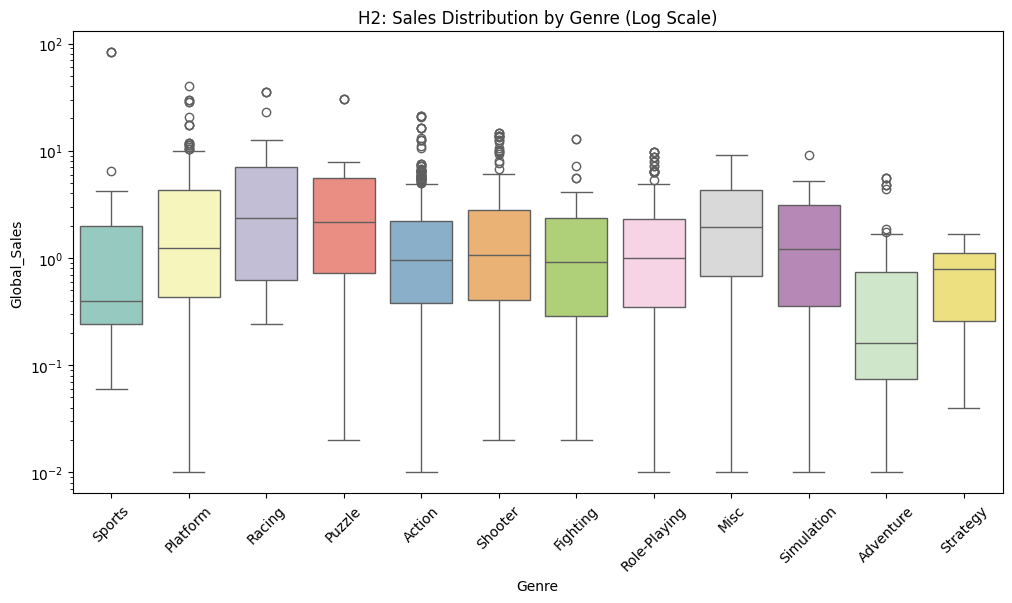

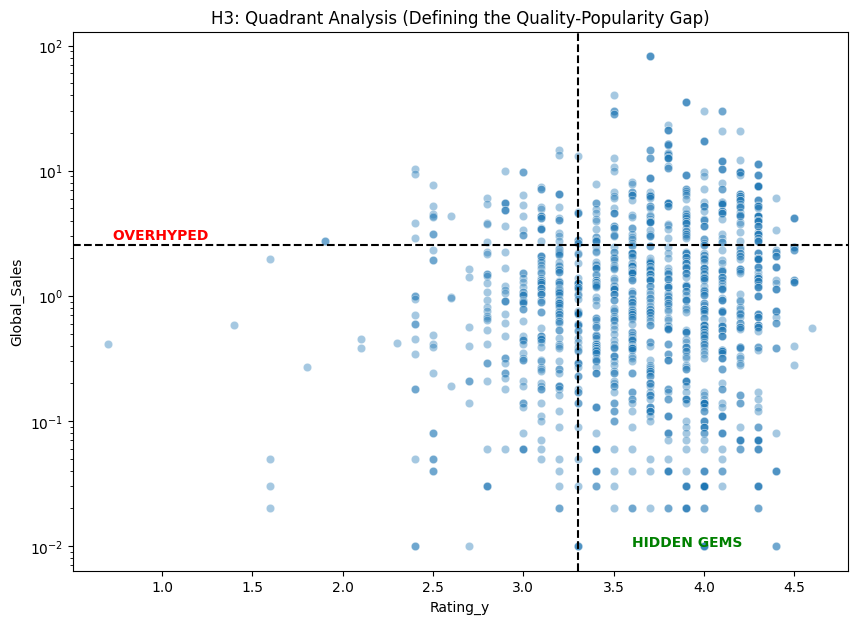

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_sales = pd.read_csv('vgsales.csv.zip')
df_popular = pd.read_csv('games.csv.zip')

df_sales['Name_Clean'] = df_sales['Name'].astype(str).str.lower().str.strip()
df_popular['Title_Clean'] = df_popular['Title'].astype(str).str.lower().str.strip()

df_merged = pd.merge(df_sales, df_popular, left_on='Name_Clean', right_on='Title_Clean', how='inner')

target_col = next((c for c in ['Rating', 'Rating_y', 'Rating_x'] if c in df_merged.columns), None)

if target_col:
    df_merged[target_col] = pd.to_numeric(df_merged[target_col], errors='coerce')
    df_merged['Global_Sales'] = pd.to_numeric(df_merged['Global_Sales'], errors='coerce')
    df_merged = df_merged.dropna(subset=['Global_Sales', target_col, 'Genre'])
    plt.figure(figsize=(10, 6))
    sns.regplot(data=df_merged, x=target_col, y='Global_Sales',
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title(f'H1: Quality ({target_col}) vs. Popularity (Global Sales)')
    plt.show()
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_merged, x='Genre', y='Global_Sales', hue='Genre', palette='Set3', legend=False)
    plt.yscale('log')
    plt.title('H2: Sales Distribution by Genre (Log Scale)')
    plt.xticks(rotation=45)
    plt.show()
    sales_q3 = df_merged['Global_Sales'].quantile(0.75)
    rating_q1 = df_merged[target_col].quantile(0.25)

    plt.figure(figsize=(10, 7))
    sns.scatterplot(data=df_merged, x=target_col, y='Global_Sales', alpha=0.4)
    plt.axhline(sales_q3, color='black', linestyle='--')
    plt.axvline(rating_q1, color='black', linestyle='--')

    plt.text(df_merged[target_col].min(), sales_q3*1.1, " OVERHYPED", color='red', weight='bold')
    plt.text(df_merged[target_col].max()-1, df_merged['Global_Sales'].min(), "HIDDEN GEMS", color='green', weight='bold')

    plt.yscale('log')
    plt.title('H3: Quadrant Analysis (Defining the Quality-Popularity Gap)')
    plt.show()
